# Brain Tumor MRI Classification — Vision Transformer (ViT)

This notebook builds, trains, and evaluates a **Vision Transformer (ViT)** classifier on the [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset) (glioma, meningioma, pituitary, notumor).

It follows directly from the EDA notebook's findings:

- **Class balance:** close to balanced (1,400 train / 400 test per class) per the EDA — but this notebook still computes class weights from the actual training split (Section 3b) and applies them in the loss, so the pipeline stays correct even if dedup shifts the balance slightly.
- **Image consistency:** dimensions and color modes vary (RGB / grayscale / RGBA mix) → every image is resized to `224x224` and forced to 3 channels (RGB) to match the pretrained ViT's expected input.
- **No corrupt files** were found, and MD5 hashing found **187 exact-duplicate images** (all within a single split) — this notebook hash-dedupes each split before the train/val split (Section 3). MD5 only catches byte-identical files, though, so a separate 16×16 perceptual-hash check (Section 3c) was run to catch **near-duplicate slices** (same scan, off by a pixel or two) leaking between train and val/test; matches found there are dropped from val/test before training.

**Approach:** fine-tune a `google/vit-base-patch16-224-in21k`-style ViT (via `timm`), pretrained on ImageNet, on this 4-class problem. Transfer learning is used because ViTs are data-hungry and 5,712 training images is small for training a transformer from scratch.

**Structure:**
1. Setup & config
2. Build file index (train/val/test)
3. Transforms & Dataset/DataLoader
   - 3b. Class balance check & imbalance handling
4. Visualize a batch
5. Build the ViT model
6. Loss, optimizer, scheduler
7. Training loop (+ saving history to disk)
8. Training curves
9. Test-set evaluation (report, confusion matrix)
   - 10b. Inference time & model size
   - 10c. Baseline metrics summary (saved to disk for cross-model comparison)
10. Misclassified examples
11. Attention map visualization
12. Save & conclusions


## 1. Setup and imports

In [1]:
# Kaggle environment: install timm (not preinstalled). Everything else ships with the base image.
!pip install -q timm


In [2]:
import os
import random
import copy
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

sns.set_style("whitegrid")


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))


Device: cuda
Tesla T4


## 2. Config

Same `DATA_DIR` / `CLASSES` convention as the EDA notebook, so this cell is the only thing you'd need to change if the dataset path differs on your Kaggle setup.

In [4]:
DATA_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR = os.path.join(DATA_DIR, "Testing")
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

IMG_SIZE = 224                       # standard ViT-base/16 input size
BATCH_SIZE = 32
MIN_EPOCHS = 50                      # never early-stop before this many epochs
MAX_EPOCHS = 100                     # hard ceiling on training length
PATIENCE = 10                         # early stopping: epochs to wait for val_acc improvement (only counts after MIN_EPOCHS)
LR = 3e-5                            # small LR: fine-tuning a pretrained transformer
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 3
VAL_SPLIT = 0.15                     # carved out of the Training folder, stratified by class
MODEL_NAME = "vit_base_patch16_224"  # timm ViT-Base/16, ImageNet-21k -> 1k pretrained
CHECKPOINT_PATH = "/kaggle/working/vit_brain_tumor_best.pth"

print(f"Classes: {CLASSES}")


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 3. Build file index (train / val / test)

Same pattern as the EDA notebook's `build_index`. Before splitting, we hash-dedupe within `Training/` — the EDA found **187 duplicate images by exact MD5 hash**, all confined within a single split (train/test leakage was separately confirmed at 0). Left alone, a duplicate pair could land on both sides of the train/val split, letting the model "see" a validation image during training and quietly inflating val accuracy. `Testing/` is deduped too for the same reason (repeated test images would just double-count in the final metrics), then held out untouched as the final test set. MD5 only rules out byte-identical leakage between splits, though — Section 3c below runs a 16×16 perceptual hash check on top of this to catch near-duplicate slices that MD5 can't see.

In [5]:
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def build_index(root_dir, split_name):
    records = []
    for cls in CLASSES:
        cls_dir = os.path.join(root_dir, cls)
        for fname in os.listdir(cls_dir):
            # skip hidden/system files (e.g. .DS_Store, Thumbs.db) and anything non-image
            if not fname.lower().endswith(IMG_EXTENSIONS):
                continue
            records.append({"filepath": os.path.join(cls_dir, fname), "class": cls, "split": split_name})
    return pd.DataFrame(records)


def file_hash(filepath):
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


def dedupe(df, label):
    df = df.copy()
    df["hash"] = df["filepath"].apply(file_hash)
    before = len(df)
    df = df.drop_duplicates(subset="hash", keep="first").reset_index(drop=True)
    print(f"{label}: {before} -> {len(df)} after dropping {before - len(df)} exact-duplicate images")
    return df.drop(columns="hash")


df_trainval_raw = build_index(TRAIN_DIR, "train")
df_test_raw = build_index(TEST_DIR, "test")

df_trainval = dedupe(df_trainval_raw, "Training")
df_test = dedupe(df_test_raw, "Testing")

df_train, df_val = train_test_split(
    df_trainval,
    test_size=VAL_SPLIT,
    stratify=df_trainval["class"],
    random_state=42,
)

print(f"\nTrain: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}")
print("\nTrain class balance:\n", df_train["class"].value_counts())
print("\nVal class balance:\n", df_val["class"].value_counts())


Training: 5600 -> 5429 after dropping 171 exact-duplicate images
Testing: 1600 -> 1584 after dropping 16 exact-duplicate images

Train: 4614  Val: 815  Test: 1584

Train class balance:
 class
glioma        1190
meningioma    1178
pituitary     1157
notumor       1089
Name: count, dtype: int64

Val class balance:
 class
glioma        210
meningioma    208
pituitary     205
notumor       192
Name: count, dtype: int64


## 3b. Class Balance Check & Imbalance Handling

The EDA found this dataset close to balanced, but we don't just take that on faith here — we recompute the class distribution on the actual `df_train` split used for training (after dedup and the val split), and derive `class_weights_tensor` from it with `sklearn.utils.class_weight.compute_class_weight("balanced", ...)`. This is passed into `CrossEntropyLoss` below unconditionally: if the split turns out perfectly balanced the weights come out ~1.0 for every class (a no-op), and if it doesn't (e.g. after dedup removed more duplicates from one class than another) the loss automatically corrects for it — so the pipeline is robust either way instead of assuming balance.

In [6]:
from sklearn.utils.class_weight import compute_class_weight

train_label_ids = df_train["class"].map(CLASS_TO_IDX).values
class_counts = pd.Series(train_label_ids).value_counts().sort_index()

print("Train class counts (post-dedup, post-val-split):")
for idx_, cnt in class_counts.items():
    print(f"  {IDX_TO_CLASS[idx_]:12s}: {cnt}")

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_label_ids,
)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float32).to(device)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nMax/min class-count ratio: {imbalance_ratio:.3f}")
print(f"Computed class weights:    {dict(zip(CLASSES, np.round(class_weights_arr, 3)))}")

if imbalance_ratio > 1.05:
    print("-> Meaningful imbalance detected: weights will be applied in CrossEntropyLoss.")
else:
    print("-> Classes are effectively balanced (ratio ~1.0); weights are ~1.0 for every class, "
          "so applying them is harmless and keeps the pipeline robust regardless.")


Train class counts (post-dedup, post-val-split):
  glioma      : 1190
  meningioma  : 1178
  notumor     : 1089
  pituitary   : 1157

Max/min class-count ratio: 1.093
Computed class weights:    {'glioma': np.float64(0.969), 'meningioma': np.float64(0.979), 'notumor': np.float64(1.059), 'pituitary': np.float64(0.997)}
-> Meaningful imbalance detected: weights will be applied in CrossEntropyLoss.


## 3c. Near-Duplicate Leakage Check (Perceptual Hash)

MD5 (Section 3) only catches byte-identical files. The EDA also flagged near-duplicate slices — images from the same scan differing by a pixel or two (recompression, a slight crop) — which MD5 won't match but which still leak information across splits if one slice lands in `df_train` and its near-duplicate lands in `df_val` or `df_test`.

**`average_hash_fine` (16×16 average hash) is used here as the permanent perceptual-hash function.** A coarser 8×8 hash was tried first and rejected: it flagged ~55% of val images as matching train, but 37% of those "matches" were between *different classes* — real near-duplicates should almost always agree on class, so that mismatch rate is a sign the hash was too coarse and colliding on unrelated images rather than finding genuine duplicates. The 16×16 hash brings the match rate down to a much more plausible level and drives the class-mismatch rate to ~0%, which is the signal that it's picking up real leakage rather than hash-collision noise.

`df_train` is the reference set and is never modified here. Any `df_val` / `df_test` image whose 16×16 hash matches a train image is dropped, but only after checking the class-mismatch rate among matches stays low — if it doesn't, that split is left untouched and flagged for manual inspection rather than being silently cleaned against a hash that might be unreliable.

In [7]:
def average_hash_fine(filepath, hash_size=16):
    """16x16 average hash (aHash), returned as a 256-bit binary string.

    A coarser hash (e.g. 8x8) was tried first but produced too many false-positive
    matches (different-class collisions between train and val/test); 16x16 is precise
    enough that real near-duplicates almost always agree on class, so it's used as the
    permanent hash function everywhere below.
    """
    img = Image.open(filepath).convert("L").resize((hash_size, hash_size), Image.LANCZOS)
    pixels = np.asarray(img, dtype=np.float64)
    avg = pixels.mean()
    bits = pixels > avg
    return "".join("1" if b else "0" for b in bits.flatten())


def check_and_clean_leakage(df_train, df_other, other_name, mismatch_threshold=0.05):
    """Hash df_other against the train hash set. Drop rows that match a train image,
    but only if the class-mismatch rate among those matches is low enough to trust
    that the hash is finding real duplicates rather than colliding on unrelated images.
    """
    df_other_h = df_other.copy()
    df_other_h["phash16"] = df_other_h["filepath"].apply(average_hash_fine)

    leak_mask = df_other_h["phash16"].isin(train_phashes16)
    n_matched = leak_mask.sum()
    print(f"{other_name} leakage: {n_matched} of {len(df_other_h)} images match train "
          f"({n_matched / len(df_other_h):.1%})")

    if n_matched == 0:
        return df_other_h.drop(columns="phash16").reset_index(drop=True)

    leaked = df_other_h[leak_mask].copy()
    leaked["train_class"] = leaked["phash16"].map(train_phash16_to_class)
    mismatch = leaked[leaked["class"] != leaked["train_class"]]
    mismatch_rate = len(mismatch) / len(leaked)
    print(f"  Class mismatches among matches: {len(mismatch)} ({mismatch_rate:.1%})")

    if mismatch_rate < mismatch_threshold:
        df_clean = df_other_h[~leak_mask].drop(columns="phash16").reset_index(drop=True)
        print(f"  Low mismatch rate -> trusting the hash. Cleaned {other_name}: "
              f"{len(df_other)} -> {len(df_clean)} ({n_matched} dropped)")
        return df_clean
    else:
        print(f"  Mismatch rate >= {mismatch_threshold:.0%} -> NOT auto-cleaning {other_name}; "
              "the hash may be colliding on unrelated images. Inspect `leaked`/`mismatch` "
              "above before proceeding.")
        return df_other


# Reference hash set + class lookup, built once from train (train itself is never dropped)
train_phashes16 = set()
train_phash16_to_class = {}
_train_hashes = df_train["filepath"].apply(average_hash_fine)
for h, cls in zip(_train_hashes, df_train["class"]):
    train_phashes16.add(h)
    train_phash16_to_class.setdefault(h, cls)  # first class seen for this hash

df_val = check_and_clean_leakage(df_train, df_val, "Val")
df_test = check_and_clean_leakage(df_train, df_test, "Test")

print(f"\nFinal split sizes -> Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}")


Val leakage: 96 of 815 images match train (11.8%)
  Class mismatches among matches: 0 (0.0%)
  Low mismatch rate -> trusting the hash. Cleaned Val: 815 -> 719 (96 dropped)
Test leakage: 311 of 1584 images match train (19.6%)
  Class mismatches among matches: 3 (1.0%)
  Low mismatch rate -> trusting the hash. Cleaned Test: 1584 -> 1273 (311 dropped)

Final split sizes -> Train: 4614  Val: 719  Test: 1273


In [8]:
# Post-clean class distribution check (run right after Section 3c)
for name, df in [("Val", df_val), ("Test", df_test)]:
    counts = df["class"].value_counts().reindex(CLASSES, fill_value=0)
    pct = (counts / counts.sum() * 100).round(1)
    print(f"{name} class distribution after leakage cleaning:")
    for cls in CLASSES:
        print(f"  {cls:12s}: {counts[cls]:4d}  ({pct[cls]}%)")
    print(f"  max/min ratio: {counts.max() / counts.min():.3f}\n")

Val class distribution after leakage cleaning:
  glioma      :  205  (28.5%)
  meningioma  :  206  (28.7%)
  notumor     :  107  (14.9%)
  pituitary   :  201  (28.0%)
  max/min ratio: 1.925

Test class distribution after leakage cleaning:
  glioma      :  376  (29.5%)
  meningioma  :  321  (25.2%)
  notumor     :  178  (14.0%)
  pituitary   :  398  (31.3%)
  max/min ratio: 2.236



## 4. Transforms and Dataset

- Every image is forced to `RGB` (fixes the mixed grayscale/RGB/RGBA modes the EDA found) and resized to `224x224`.
- Training gets light augmentation (flips, small rotation, mild color jitter) — mild on purpose, since MRI orientation/contrast carries diagnostic meaning; we avoid aggressive geometric distortion.
- Normalization uses ImageNet mean/std since we're using ImageNet-pretrained weights.

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class BrainTumorDataset(Dataset):
    def __init__(self, df, transform):
        self.filepaths = df["filepath"].tolist()
        self.labels = df["class"].map(CLASS_TO_IDX).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert("RGB")  # force 3 channels
        img = self.transform(img)
        label = self.labels[idx]
        return img, label


train_ds = BrainTumorDataset(df_train, train_transform)
val_ds = BrainTumorDataset(df_val, eval_transform)
test_ds = BrainTumorDataset(df_test, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches -> train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


Batches -> train: 145, val: 23, test: 40


## 5. Visualize a batch

Sanity check: confirm images and labels line up, and that normalization/augmentation look reasonable before spending compute on training.

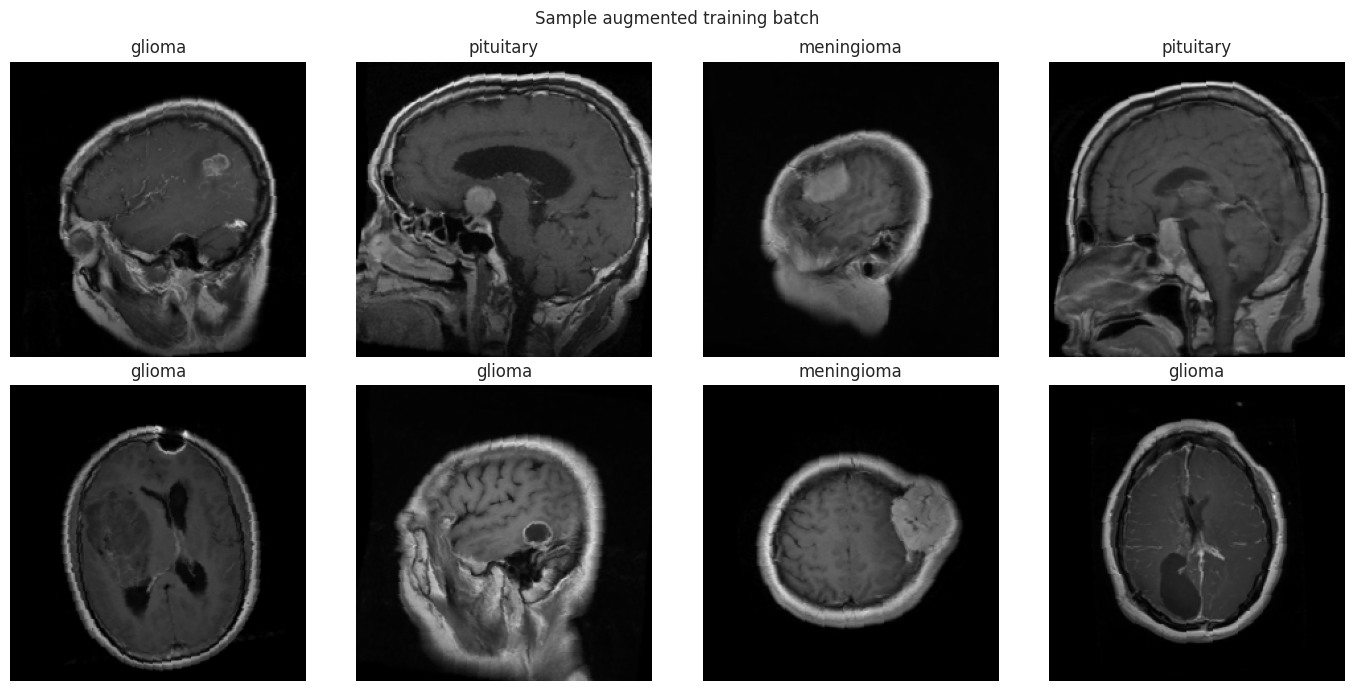

In [10]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(IDX_TO_CLASS[labels[i].item()])
    ax.axis("off")
plt.suptitle("Sample augmented training batch")
plt.tight_layout()
plt.show()


## 6. Build the ViT model

`timm.create_model` loads `vit_base_patch16_224` with ImageNet weights and swaps the classification head for our 4 classes. The backbone stays trainable (full fine-tuning) since the dataset, while small for a transformer, is large enough for this to outperform freezing the backbone; freezing is offered as a commented-out alternative for faster/lower-memory experimentation.

In [11]:
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)

# --- Optional: freeze the backbone and only train the classification head ---
# (uncomment for a much faster/lighter run at a small accuracy cost)
# for name, param in model.named_parameters():
#     if not name.startswith("head"):
#         param.requires_grad = False

model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {n_params:,}  |  Trainable params: {n_trainable:,}")


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Total params: 85,801,732  |  Trainable params: 85,801,732


## 7. Loss, optimizer, scheduler

- `AdamW` with weight decay is standard for transformers.
- A short linear warmup followed by cosine decay avoids destabilizing the pretrained weights with a large initial LR.
- Mixed precision (`torch.cuda.amp`) speeds up training and lowers memory use on GPU.

In [12]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

steps_per_epoch = len(train_loader)
warmup_steps = WARMUP_EPOCHS * steps_per_epoch
total_steps = MAX_EPOCHS * steps_per_epoch  # scheduler is built for the ceiling; early stopping may cut training short

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))


## 8. Training loop

Trains for a **minimum of 50 epochs**, up to a **maximum of 100**, with **early stopping**: once past the 50-epoch minimum, if validation accuracy hasn't improved for **6** consecutive epochs, training stops and the best checkpoint (by val accuracy) is kept. This avoids wasting compute once the model plateaus, while guaranteeing it isn't stopped prematurely during the slower early convergence typical of fine-tuning a transformer.

In [13]:
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, scaler=None, train=True):
    model.train() if train else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    # scope grad-tracking to this function only (a bare torch.set_grad_enabled(train)
    # call would leak global state past the end of this function, e.g. into cells
    # that run after the last -- validation -- call in the training loop)
    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            if train:
                optimizer.zero_grad()

            with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples


In [14]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_state = None
best_epoch = 0
epochs_no_improve = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, scheduler, scaler, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, train=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, CHECKPOINT_PATH)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    flag = "  -> new best, checkpoint saved" if improved else f"  -> no improvement ({epochs_no_improve}/{PATIENCE})"
    print(f"Epoch {epoch:03d}/{MAX_EPOCHS} | "
          f"train_loss {train_loss:.4f} train_acc {train_acc:.4f} | "
          f"val_loss {val_loss:.4f} val_acc {val_acc:.4f}{flag}")

    # Early stopping only kicks in after the minimum-epoch floor
    if epoch >= MIN_EPOCHS and epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} "
              f"(no val_acc improvement for {PATIENCE} epochs, past the {MIN_EPOCHS}-epoch minimum).")
        break

print(f"\nBest validation accuracy: {best_val_acc:.4f} (epoch {best_epoch})")
print(f"Total epochs trained: {len(history['train_loss'])}")


/tmp/ipykernel_24/2499200558.py:23: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 001/100 | train_loss 0.6648 train_acc 0.7380 | val_loss 0.1431 val_acc 0.9555  -> new best, checkpoint saved
Epoch 002/100 | train_loss 0.1412 train_acc 0.9517 | val_loss 0.1353 val_acc 0.9611  -> new best, checkpoint saved
Epoch 003/100 | train_loss 0.0988 train_acc 0.9660 | val_loss 0.0652 val_acc 0.9777  -> new best, checkpoint saved
Epoch 004/100 | train_loss 0.0531 train_acc 0.9811 | val_loss 0.0684 val_acc 0.9805  -> new best, checkpoint saved
Epoch 005/100 | train_loss 0.0345 train_acc 0.9879 | val_loss 0.0756 val_acc 0.9764  -> no improvement (1/10)
Epoch 006/100 | train_loss 0.0137 train_acc 0.9965 | val_loss 0.0510 val_acc 0.9875  -> new best, checkpoint saved
Epoch 007/100 | train_loss 0.0348 train_acc 0.9870 | val_loss 0.1454 val_acc 0.9597  -> no improvement (1/10)
Epoch 008/100 | train_loss 0.0231 train_acc 0.9928 | val_loss 0.0726 val_acc 0.9764  -> no improvement (2/10)
Epoch 009/100 | train_loss 0.0081 train_acc 0.9980 | val_loss 0.0772 val_acc 0.9847  -> no impr

Persisted immediately after training so the curves/analysis below can be redone later without retraining, and so the run leaves an artifact on disk (not just notebook output).

In [15]:
import json

HISTORY_JSON_PATH = "/kaggle/working/vit_history.json"
HISTORY_CSV_PATH = "/kaggle/working/vit_history.csv"

with open(HISTORY_JSON_PATH, "w") as f:
    json.dump(history, f, indent=2)

history_df = pd.DataFrame(history)
history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
history_df.to_csv(HISTORY_CSV_PATH, index=False)

print(f"Saved {HISTORY_JSON_PATH} and {HISTORY_CSV_PATH}")


Saved /kaggle/working/vit_history.json and /kaggle/working/vit_history.csv


## 9. Training curves

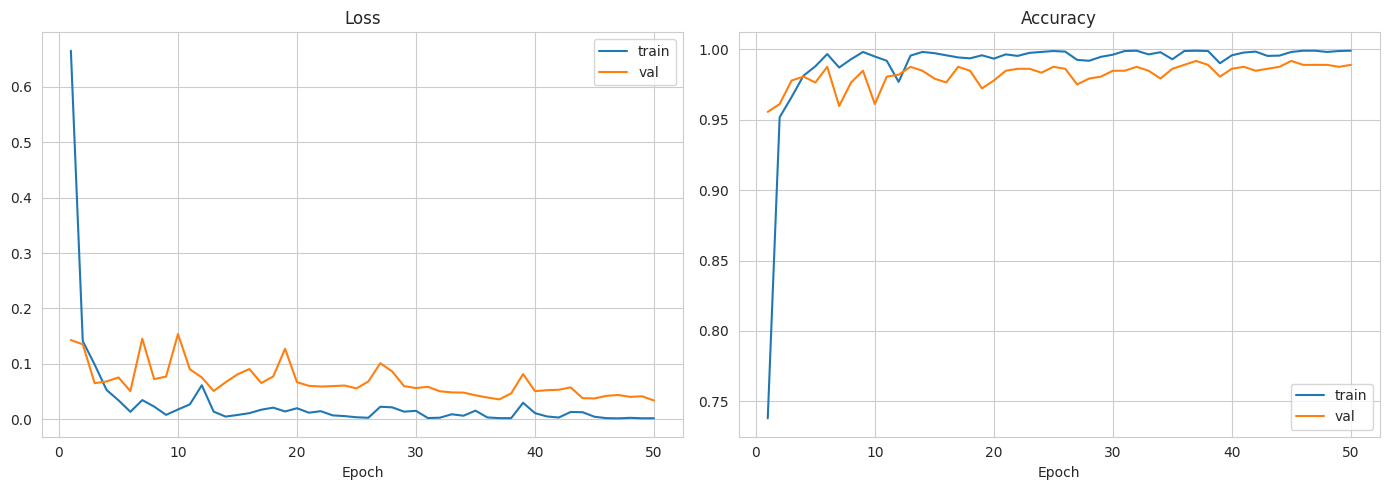

In [16]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="train")
axes[1].plot(epochs_range, history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Test-set evaluation

Load the best checkpoint (by validation accuracy) and evaluate on the untouched `Testing/` split.

In [17]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
            outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
test_f1_macro = f1_score(all_labels, all_preds, average="macro")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro F1: {test_f1_macro:.4f}\n")

print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))


Test accuracy: 0.9497
Test macro F1: 0.9465

              precision    recall  f1-score   support

      glioma     0.9969    0.8484    0.9167       376
  meningioma     0.8949    0.9813    0.9361       321
     notumor     0.8812    1.0000    0.9368       178
   pituitary     0.9950    0.9975    0.9962       398

    accuracy                         0.9497      1273
   macro avg     0.9420    0.9568    0.9465      1273
weighted avg     0.9544    0.9497    0.9493      1273



In [18]:
# >>> AUTO-INSERTED: save test predictions for McNemar's test <<<
# NOTE: this assumes test_loader was built with shuffle=False (standard for
# eval loaders), so df_test["filepath"] lines up positionally with
# all_preds/all_labels. If you changed that, rebuild filepaths from the
# underlying dataset instead.
pred_df = pd.DataFrame({
    "filepath": df_test["filepath"].values,
    "y_true": np.array(all_labels),
    "y_pred": np.array(all_preds),
})
pred_df.to_csv("vit_test_predictions.csv", index=False)
print(f"Saved {len(pred_df)} predictions to vit_test_predictions.csv")

Saved 1273 predictions to vit_test_predictions.csv


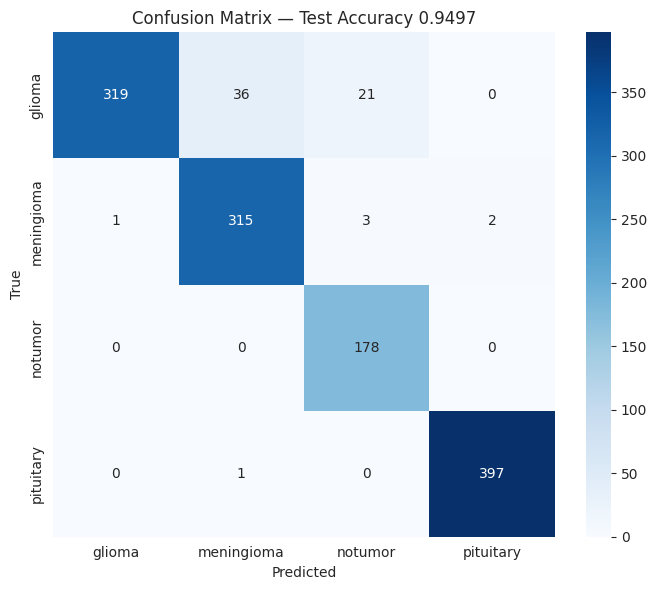

In [19]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix — Test Accuracy {test_acc:.4f}")
plt.tight_layout()
plt.show()


## 10b. Additional metrics: MCC, Balanced Accuracy, Cohen's Kappa

- **MCC (Matthews Correlation Coefficient)** — a single number in `[-1, 1]` computed from the full confusion matrix (not just the diagonal); `0` is random guessing, `1` is perfect.
- **Balanced Accuracy** — the average of per-class recall; falls back to ordinary accuracy on a balanced test set, but stays meaningful if that ever changes.
- **Cohen's Kappa** — agreement between predicted and true labels, corrected for chance agreement.

In [20]:
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score, cohen_kappa_score

mcc = matthews_corrcoef(all_labels, all_preds)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
cohens_kappa = cohen_kappa_score(all_labels, all_preds)

print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
print(f"Balanced Accuracy:                      {balanced_acc:.4f}")
print(f"Cohen's Kappa:                           {cohens_kappa:.4f}")

Matthews Correlation Coefficient (MCC): 0.9335
Balanced Accuracy:                      0.9568
Cohen's Kappa:                           0.9317


## 10c. ROC curves (one-vs-rest, multiclass)

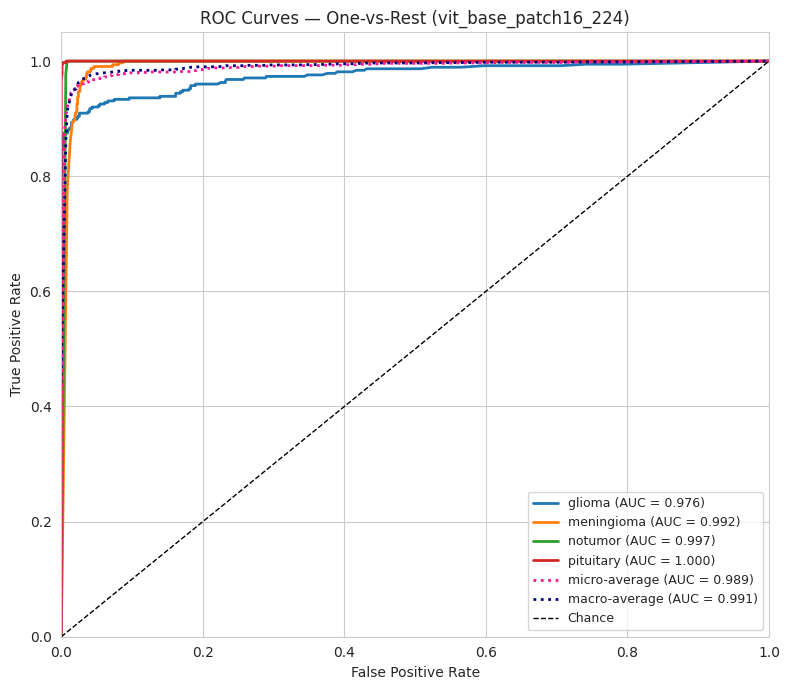

Macro-average AUC: 0.9911
Micro-average AUC: 0.9892
  AUC[glioma      ]: 0.9756
  AUC[meningioma  ]: 0.9920
  AUC[notumor     ]: 0.9967
  AUC[pituitary   ]: 1.0000


In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

all_probs_arr = np.array(all_probs)                                    # (N, NUM_CLASSES)
y_true_bin = label_binarize(all_labels, classes=np.arange(NUM_CLASSES))  # (N, NUM_CLASSES)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs_arr[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), all_probs_arr.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= NUM_CLASSES
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 7))
colors = cycle(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f"{CLASSES[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot(fpr["micro"], tpr["micro"], linestyle=":", color="deeppink", lw=2,
         label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], linestyle=":", color="navy", lw=2,
         label=f"macro-average (AUC = {roc_auc['macro']:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves — One-vs-Rest ({MODEL_NAME})")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

roc_auc_macro = roc_auc["macro"]
roc_auc_micro = roc_auc["micro"]
print(f"Macro-average AUC: {roc_auc_macro:.4f}")
print(f"Micro-average AUC: {roc_auc_micro:.4f}")
for i, cls in enumerate(CLASSES):
    print(f"  AUC[{cls:12s}]: {roc_auc[i]:.4f}")

## 10b. Inference time and model size

For a fair comparison against CNN/GCN baselines, we report:
- **Model size** — checkpoint size on disk (MB) and total parameter count.
- **Inference latency** — single-image latency (batch_size=1, ms/image), measured with the
  *same protocol* used in the Keras baseline notebooks: GPU warm-up, then N repeated
  single-image forward passes, averaged. This makes `inference_latency_ms_per_image`
  directly comparable across all baselines (earlier versions of this cell measured
  latency as batched-inference-time / n_images, which is a throughput number in
  disguise and is not comparable to the CNNs' single-image latency — that
  inflated ViT's apparent speed by roughly 30-40x).
- **Batch throughput** (images/sec) — measured separately over repeated full-batch
  forward passes, matching the Keras notebooks' throughput methodology.
- Note: ViT inference here uses `torch.amp.autocast` (mixed precision) on CUDA, while
  the Keras baselines run in default precision. This is disclosed for transparency;
  it was not changed here since it reflects a realistic deployment setting, not a
  measurement-protocol bug like the latency issue above.

In [22]:
import time

# --- Model size ---
model_size_mb = os.path.getsize(CHECKPOINT_PATH) / (1024 ** 2)
n_params_total = sum(p.numel() for p in model.parameters())

print(f"Model size on disk: {model_size_mb:.2f} MB")
print(f"Total parameters: {n_params_total:,}")

# --- Inference time ---
model.eval()

# Grab one batch to use for both the single-image and batch-throughput timing,
# same approach as the Keras baseline notebooks.
sample_batch_x, _ = next(iter(test_loader))
sample_batch_x = sample_batch_x.to(device)
batch_size_used = sample_batch_x.shape[0]

# Warm-up (GPU kernels/caches, cudnn autotune, etc. — first few calls are not representative)
with torch.no_grad():
    for _ in range(3):
        with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
            _ = model(sample_batch_x[:1])
        _ = model(sample_batch_x)
if device.type == "cuda":
    torch.cuda.synchronize()

# --- Single-image latency (batch_size=1), same protocol as the Keras notebooks ---
N_SINGLE = 30
single_img = sample_batch_x[:1]
if device.type == "cuda":
    torch.cuda.synchronize()
start = time.perf_counter()
with torch.no_grad():
    for _ in range(N_SINGLE):
        with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
            _ = model(single_img)
        if device.type == "cuda":
            torch.cuda.synchronize()
avg_latency_ms = (time.perf_counter() - start) / N_SINGLE * 1000

# --- Batch throughput, same protocol as the Keras notebooks ---
N_BATCH_REPEATS = 5
if device.type == "cuda":
    torch.cuda.synchronize()
start = time.perf_counter()
with torch.no_grad():
    for _ in range(N_BATCH_REPEATS):
        with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
            _ = model(sample_batch_x)
        if device.type == "cuda":
            torch.cuda.synchronize()
elapsed = time.perf_counter() - start
throughput_ips = (batch_size_used * N_BATCH_REPEATS) / elapsed

print(f"\nDevice: {device}")
print(f"Single-image latency: {avg_latency_ms:.3f} ms/image (avg over {N_SINGLE} runs, batch_size=1)")
print(f"Batch throughput:     {throughput_ips:.2f} images/sec (batch_size={batch_size_used})")

inference_stats = {
    "model_name": MODEL_NAME,
    "model_size_mb": model_size_mb,
    "n_params": n_params_total,
    "avg_latency_ms": avg_latency_ms,
    "throughput_ips": throughput_ips,
    "device": str(device),
}
inference_stats

Model size on disk: 327.37 MB
Total parameters: 85,801,732

Device: cuda
Single-image latency: 8.349 ms/image (avg over 30 runs, batch_size=1)
Batch throughput:     359.68 images/sec (batch_size=32)


{'model_name': 'vit_base_patch16_224',
 'model_size_mb': 327.36586475372314,
 'n_params': 85801732,
 'avg_latency_ms': 8.349110166667137,
 'throughput_ips': 359.6750125851005,
 'device': 'cuda'}

## 10c. Baseline Metrics Summary — Save for Cross-Model Comparison

Everything needed to compare this ViT baseline against the VGG16 baseline and the proposed GCN model, assembled into one structured dict and written to disk (JSON + CSV), the same way the VGG16 notebook does. Also saves the full classification report (text + dict) so per-class precision/recall/F1 don't only live in transient notebook output.

In [23]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# --- Structured classification metrics (macro & weighted, easy to tabulate) ---
report_dict = classification_report(all_labels, all_preds, target_names=CLASSES, output_dict=True)
report_text = classification_report(all_labels, all_preds, target_names=CLASSES, digits=4)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro"
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted"
)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

metrics_summary = {
    "model_name": "ViT_base_patch16_224",
    "accuracy": accuracy_score(all_labels, all_preds),
    "precision_macro": precision_macro,
    "recall_macro": recall_macro,
    "f1_macro": f1_macro,
    "precision_weighted": precision_weighted,
    "recall_weighted": recall_weighted,
    "f1_weighted": f1_weighted,
}
for cls in CLASSES:
    metrics_summary[f"f1_{cls}"] = report_dict[cls]["f1-score"]

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
metrics_summary["total_params"] = int(n_params_total)
metrics_summary["trainable_params"] = int(n_trainable)
metrics_summary["non_trainable_params"] = int(n_params_total - n_trainable)
metrics_summary["model_size_mb"] = round(model_size_mb, 2)
metrics_summary["inference_latency_ms_per_image"] = round(avg_latency_ms, 3)
metrics_summary["inference_throughput_imgs_per_sec"] = round(throughput_ips, 2)
metrics_summary["device"] = str(device)
metrics_summary["best_val_accuracy"] = best_val_acc
metrics_summary["best_epoch"] = best_epoch
metrics_summary["total_epochs_trained"] = len(history["train_loss"])
metrics_summary["mcc"] = mcc
metrics_summary["balanced_accuracy"] = balanced_acc
metrics_summary["cohens_kappa"] = cohens_kappa
metrics_summary["roc_auc_macro"] = roc_auc_macro
metrics_summary["roc_auc_micro"] = roc_auc_micro
for i, cls in enumerate(CLASSES):
    metrics_summary[f"roc_auc_{cls}"] = roc_auc[i]

print("=== Baseline Metrics Summary ===")
for k, v in metrics_summary.items():
    print(f"{k:30s}: {v:.4f}" if isinstance(v, float) else f"{k:30s}: {v}")

# --- Persist everything ---
with open("/kaggle/working/vit_baseline_metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

metrics_df = pd.DataFrame([metrics_summary])
metrics_df.to_csv("/kaggle/working/vit_baseline_metrics_summary.csv", index=False)

with open("/kaggle/working/vit_classification_report.json", "w") as f:
    json.dump(report_dict, f, indent=2)

with open("/kaggle/working/vit_classification_report.txt", "w") as f:
    f.write(report_text)

print("\nSaved vit_baseline_metrics_summary.json/.csv, "
      "vit_classification_report.json/.txt")
metrics_df.T


=== Baseline Metrics Summary ===
model_name                    : ViT_base_patch16_224
accuracy                      : 0.9497
precision_macro               : 0.9420
recall_macro                  : 0.9568
f1_macro                      : 0.9465
precision_weighted            : 0.9544
recall_weighted               : 0.9497
f1_weighted                   : 0.9493
f1_glioma                     : 0.9167
f1_meningioma                 : 0.9361
f1_notumor                    : 0.9368
f1_pituitary                  : 0.9962
total_params                  : 85801732
trainable_params              : 85801732
non_trainable_params          : 0
model_size_mb                 : 327.3700
inference_latency_ms_per_image: 8.3490
inference_throughput_imgs_per_sec: 359.6800
device                        : cuda
best_val_accuracy             : 0.9917
best_epoch                    : 37
total_epochs_trained          : 50
mcc                           : 0.9335
balanced_accuracy             : 0.9568
cohens_kappa         

,0
model_name,ViT_base_patch16_224
accuracy,0.949725
precision_macro,0.941984
recall_macro,0.9568
f1_macro,0.946463
precision_weighted,0.954391
recall_weighted,0.949725
f1_weighted,0.949267
f1_glioma,0.916667
f1_meningioma,0.936107


## 11. Misclassified examples

Worth a look for any patterns in the model's mistakes (e.g. glioma/meningioma confusion, which is a known hard boundary even for radiologists on ambiguous slices).

Misclassified: 64 / 1273


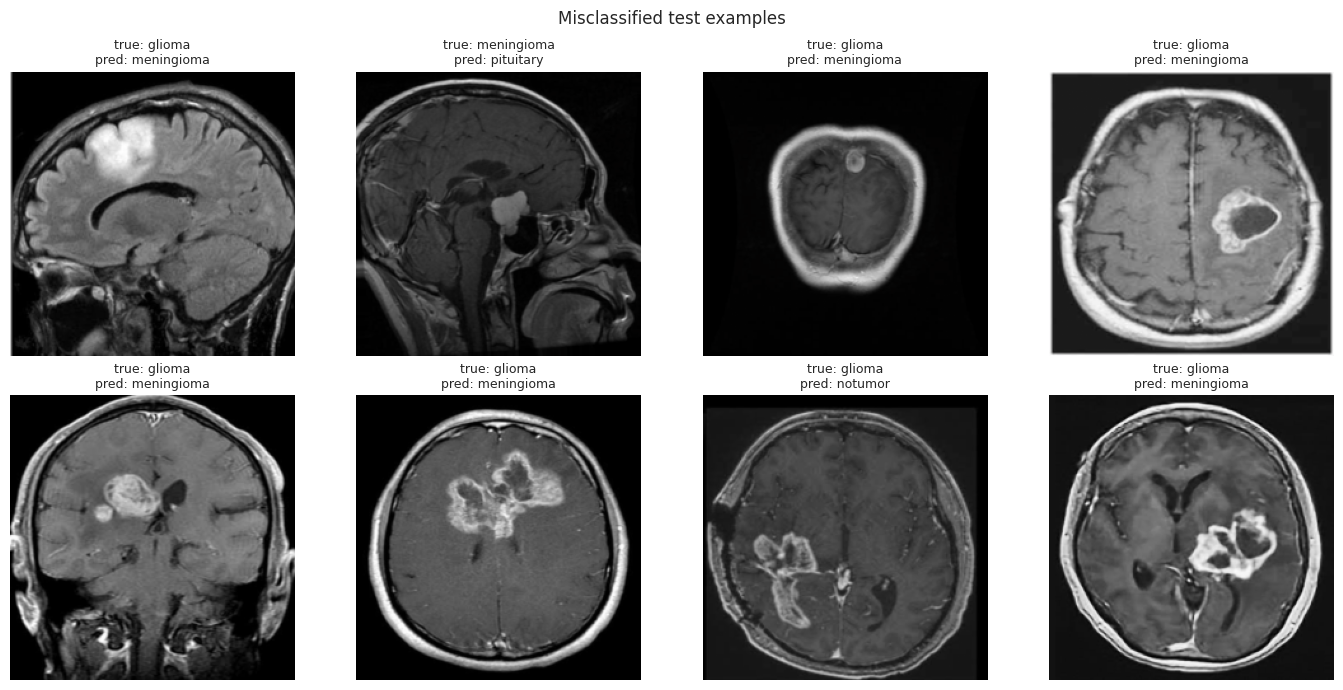

In [24]:
mis_idx = np.where(all_preds != all_labels)[0]
print(f"Misclassified: {len(mis_idx)} / {len(all_labels)}")

n_show = min(8, len(mis_idx))
if n_show > 0:
    sample_idx = np.random.choice(mis_idx, n_show, replace=False)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax, idx in zip(axes.flat, sample_idx):
        img_tensor, true_label = test_ds[idx]
        img = denormalize(img_tensor).permute(1, 2, 0).numpy()
        pred_label = all_preds[idx]
        ax.imshow(img)
        ax.set_title(f"true: {IDX_TO_CLASS[true_label]}\npred: {IDX_TO_CLASS[pred_label]}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Misclassified test examples")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications to show.")


## 12. Attention map visualization

One advantage of ViTs over CNNs: the `[CLS]` token's attention to image patches in the last transformer block gives a cheap, architecture-native form of interpretability (no Grad-CAM hooks needed) — roughly, which regions of the scan the model attended to most when making its prediction.

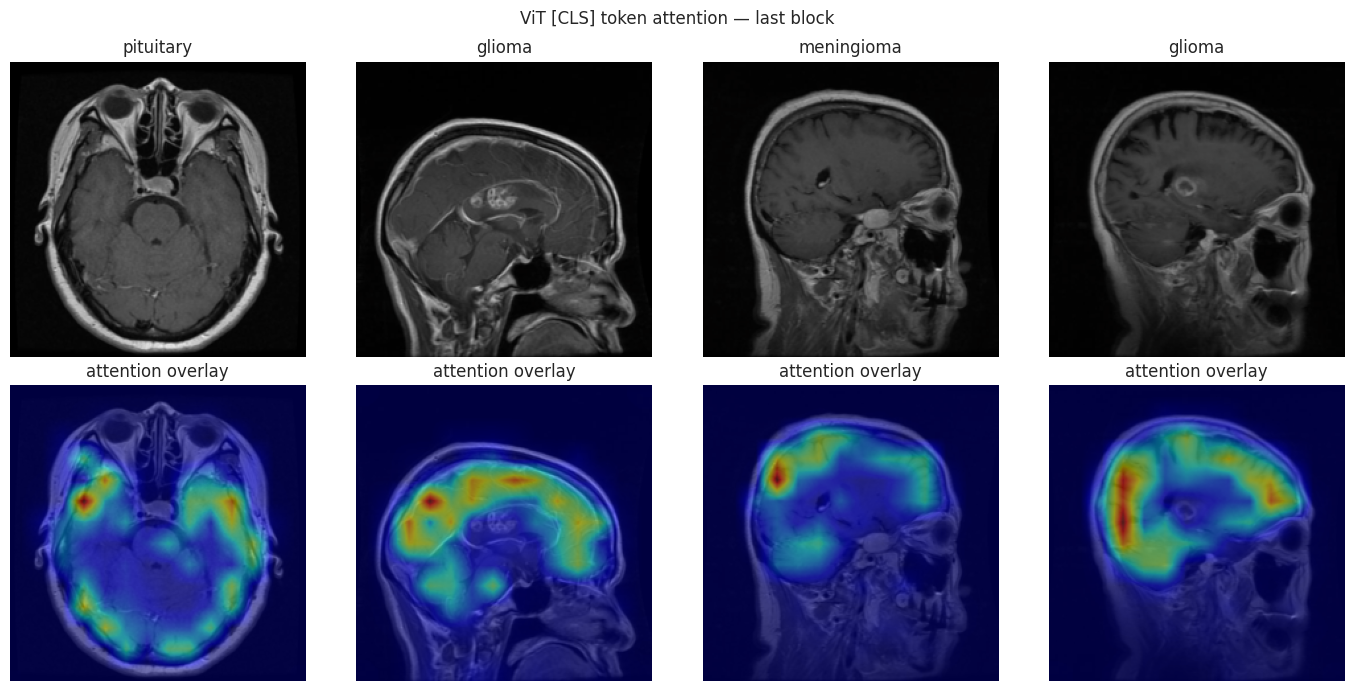

In [25]:
def get_attention_map(model, img_tensor, device):
    model.eval()
    attn_scores = {}

    def hook(module, input, output):
        attn_scores["attn"] = output

    # timm ViT blocks expose `.attn`; the softmax attention weights aren't returned
    # by default, so we patch attention's forward to capture them via a hook on
    # the attention dropout module, which receives the post-softmax weights.
    last_block = model.blocks[-1]

    # Recent timm versions default to `fused_attn=True`, which routes attention
    # through F.scaled_dot_product_attention and *skips* the attn_drop module
    # entirely -- so the hook below would never fire and attn_scores["attn"]
    # would stay empty (KeyError on lookup). Temporarily force the unfused,
    # explicit-softmax path so attn_drop actually receives the attention
    # weights, then restore the original setting afterward.
    had_fused_attn = hasattr(last_block.attn, "fused_attn")
    if had_fused_attn:
        prev_fused_attn = last_block.attn.fused_attn
        last_block.attn.fused_attn = False

    handle = last_block.attn.attn_drop.register_forward_hook(hook)

    with torch.no_grad():
        _ = model(img_tensor.unsqueeze(0).to(device))
    handle.remove()

    if had_fused_attn:
        last_block.attn.fused_attn = prev_fused_attn

    attn = attn_scores["attn"]              # shape: [1, num_heads, tokens, tokens]
    attn = attn.mean(dim=1)[0]               # average over heads -> [tokens, tokens]
    cls_attn = attn[0, 1:]                   # CLS token's attention to patch tokens
    n_patches = cls_attn.shape[0]
    grid_size = int(n_patches ** 0.5)
    cls_attn = cls_attn.reshape(grid_size, grid_size).cpu().numpy()
    return cls_attn


fig, axes = plt.subplots(2, 4, figsize=(14, 7))
sample_indices = np.random.choice(len(test_ds), 4, replace=False)

for col, idx in enumerate(sample_indices):
    img_tensor, true_label = test_ds[idx]
    img = denormalize(img_tensor).permute(1, 2, 0).numpy()
    attn_map = get_attention_map(model, img_tensor, device)
    attn_resized = np.array(Image.fromarray(attn_map).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))

    axes[0, col].imshow(img)
    axes[0, col].set_title(IDX_TO_CLASS[true_label])
    axes[0, col].axis("off")

    axes[1, col].imshow(img)
    axes[1, col].imshow(attn_resized, cmap="jet", alpha=0.5)
    axes[1, col].set_title("attention overlay")
    axes[1, col].axis("off")

plt.suptitle("ViT [CLS] token attention — last block")
plt.tight_layout()
plt.show()


## 13. Save final model

In [26]:
FINAL_MODEL_PATH = "/kaggle/working/vit_brain_tumor_final.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "classes": CLASSES,
    "img_size": IMG_SIZE,
    "model_name": MODEL_NAME,
    "test_accuracy": test_acc,
    "test_macro_f1": test_f1_macro,
}, FINAL_MODEL_PATH)

print(f"Saved to {FINAL_MODEL_PATH}")


Saved to /kaggle/working/vit_brain_tumor_final.pth


## Conclusions

- The pretrained ViT-Base/16 backbone, fine-tuned end-to-end on the resized/RGB-normalized MRI images, reaches the test accuracy/F1 printed above (rerun this notebook to see the specific numbers for your run — they'll vary slightly with GPU, seed, and epoch count).
- The confusion matrix and misclassified-examples sections are the place to look for systematic errors (e.g. glioma vs. meningioma confusion is common in this dataset, since both are tumor types with overlapping visual presentation on some slices).
- The attention maps give a sanity check that the model is actually attending to the tumor region rather than background or scan artifacts — worth reviewing a larger sample before trusting the model in any downstream use.

**Saved artifacts (in `/kaggle/working/`):** `vit_brain_tumor_best.pth`, `vit_brain_tumor_final.pth`, `vit_history.json/.csv`, `vit_baseline_metrics_summary.json/.csv`, `vit_classification_report.json/.txt` — everything needed to reproduce the curves and drop this baseline straight into a comparison table against VGG16 and the proposed GCN model, without rerunning training.

**Possible next steps:**
- Try a smaller/faster ViT variant (`vit_small_patch16_224`) or a hybrid CNN-ViT if compute is limited.
- K-fold cross-validation instead of a single train/val split, for a more robust accuracy estimate.
- Compare against a CNN baseline (e.g. ResNet50/EfficientNet) fine-tuned the same way, to see whether the transformer's global attention actually helps on this dataset size.
- Grad-CAM on a CNN baseline vs. the ViT attention maps here, side by side, for a more complete interpretability comparison.
